## Coursework 2 Group (text)

Group number: 29

Student names and k-numbers:
1. Kishan Bangsi Magar - K2545729
2. Pradeep Appasaheb Nayak - K2520606
3. Shweta Patankar - K2557766
4. Daniel Rolon Rodriguez - K2552225

# Load modules (code)

## Environment detection

In [2]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

print("Running in Colab:", IN_COLAB)
print("Colab push")

Running in Colab: False
Colab push


In [3]:
# Install dependencies
if IN_COLAB:
    import sys
    !git clone https://github.com/4yala/NotebooksDL
    %cd NotebooksDL
    !{sys.executable} -m pip install -r requirements.txt

#Deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

#Data handling
import numpy as np
import random
import math

# Dataset
import medmnist
from medmnist import INFO

# Pre-processing / Utilities
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

I0000 00:00:1775696704.986782   10919 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775696705.398551   10919 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775696707.095070   10919 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Load data

In [4]:
#Dataset selection
data_flag = "organsmnist"
info = INFO[data_flag]
data_root = "./data"
DataClass = getattr(medmnist, info["python_class"])

#Dataset loading
train_dataset = DataClass(split="train", download=True, size=224, root=data_root)
val_dataset   = DataClass(split="val", download=True, size=224, root=data_root)
test_dataset  = DataClass(split="test", download=True, size=224, root=data_root)

#NumPy formatting
X_train, y_train = train_dataset.imgs, train_dataset.labels
X_val, y_val     = val_dataset.imgs, val_dataset.labels
X_test, y_test   = test_dataset.imgs, test_dataset.labels


## Preprocess data

In [5]:
#Normalise data
X_train_normal = X_train / 255.0
X_val_normal   = X_val / 255.0
X_test_normal  = X_test / 255.0

#Flatten data
X_train_flat = X_train_normal.reshape(len(X_train_normal), -1)
X_val_flat   = X_val_normal.reshape(len(X_val_normal), -1)
X_test_flat  = X_test_normal.reshape(len(X_test_normal), -1)

# Initial Visualisation

## Basic observations

In [7]:
#Dataset shape checks
print("Train shape:")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nValidation shape:")
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTest shape:")
print("X:", X_test.shape)
print("y:", y_test.shape)

#Label visualisation
print("\nNumber of classes:", len(info["label"]))
print("Class labels:")
for idx, name in info["label"].items():
    print(f"{idx}: {name}")

Train shape:
X: (13932, 224, 224)
y: (13932, 1)

Validation shape:
X: (2452, 224, 224)
y: (2452, 1)

Test shape:
X: (8827, 224, 224)
y: (8827, 1)

Number of classes: 11
Class labels:
0: bladder
1: femur-left
2: femur-right
3: heart
4: kidney-left
5: kidney-right
6: liver
7: lung-left
8: lung-right
9: pancreas
10: spleen


##Class balance observation

### Setup

In [8]:
class_names = list(info["label"].values())
num_classes = len(class_names)

def get_class_counts(labels, num_classes):
    counts = np.zeros(num_classes)

    # labels often come as shape (N, 1)
    labels = np.squeeze(labels)

    for l in labels:
        counts[int(l)] += 1

    return counts

def plot_histogram(counts, title):
    plt.figure(figsize=(10,5))
    plt.bar(class_names, counts)
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.ylabel("Number of samples")
    plt.tight_layout()
    print("\n")
    plt.show()

def plot_pie(counts, title):
    plt.figure(figsize=(8,8))
    colours = plt.cm.tab20(np.linspace(0, 1, len(counts)))
    plt.pie(counts, labels=class_names, autopct='%1.1f%%', colors=colours)
    plt.title(title)
    print("\n")
    plt.show()

### Train split

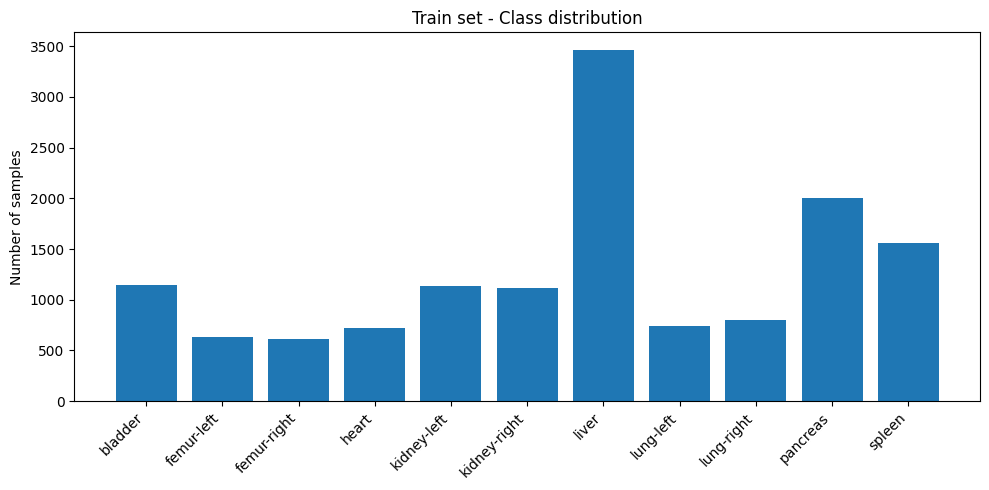

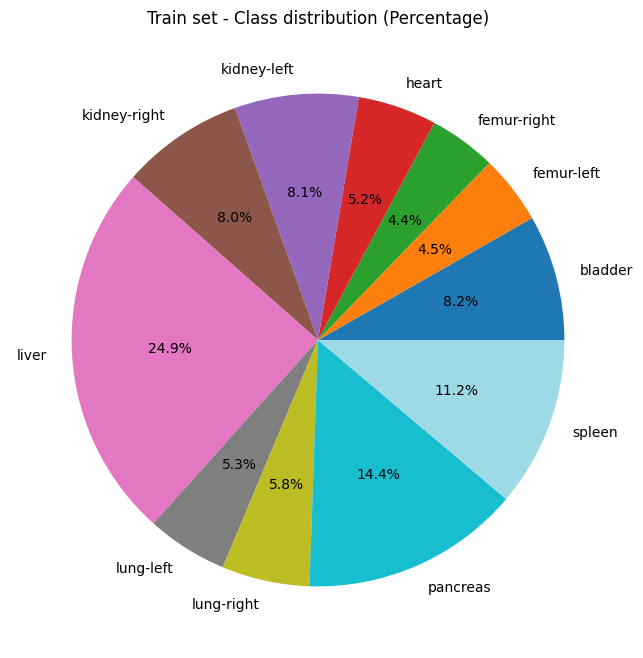

In [ ]:
train_counts = get_class_counts(y_train, num_classes)
plot_histogram(train_counts, "Train set - Class distribution")
plot_pie(train_counts, "Train set - Class distribution (Percentage)")

### Validation split


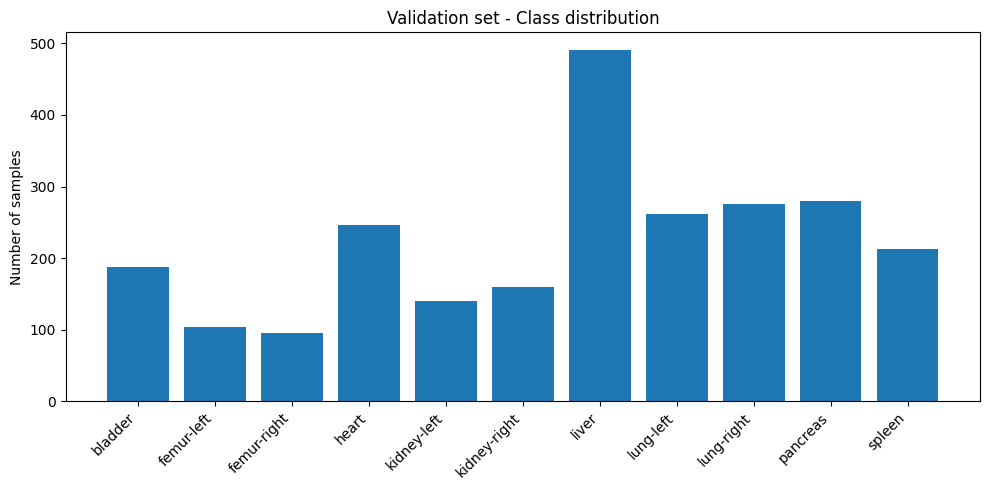

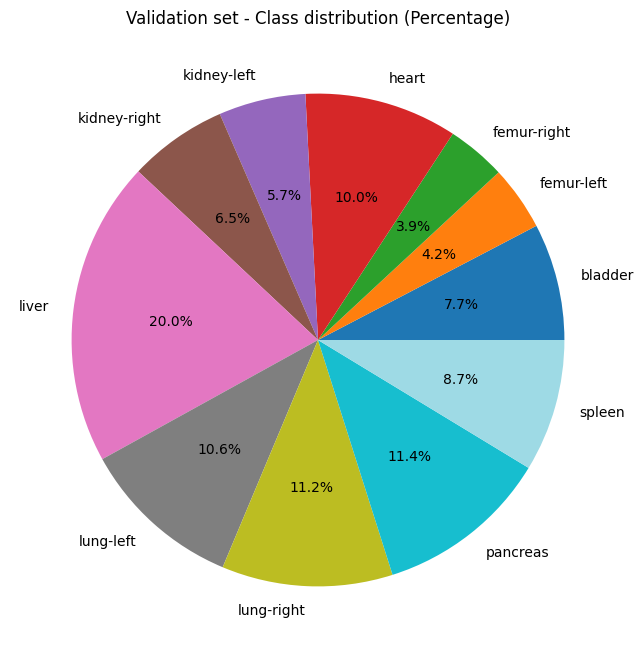

In [ ]:
val_counts   = get_class_counts(y_val, num_classes)
plot_histogram(val_counts, "Validation set - Class distribution")
plot_pie(val_counts, "Validation set - Class distribution (Percentage)")


### Test split

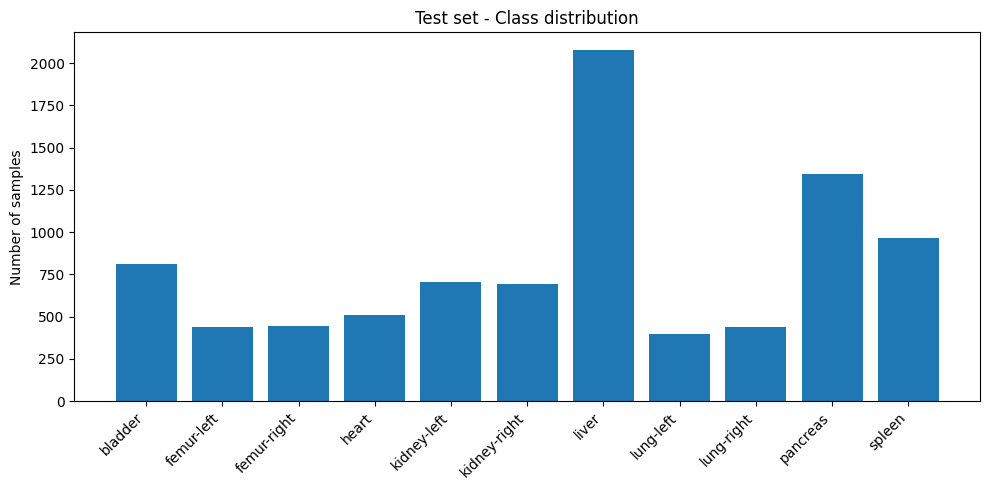

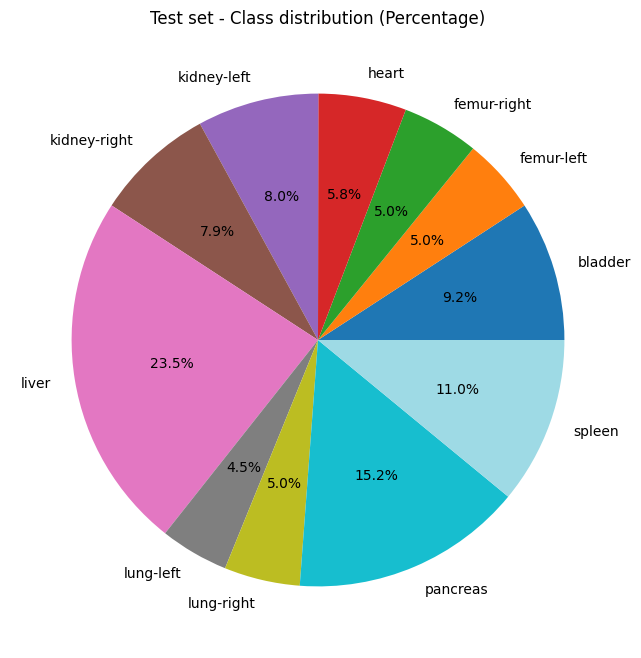

In [ ]:
test_counts  = get_class_counts(y_test, num_classes)
plot_histogram(test_counts, "Test set - Class distribution")
plot_pie(test_counts, "Test set - Class distribution (Percentage)")

### Split comparison

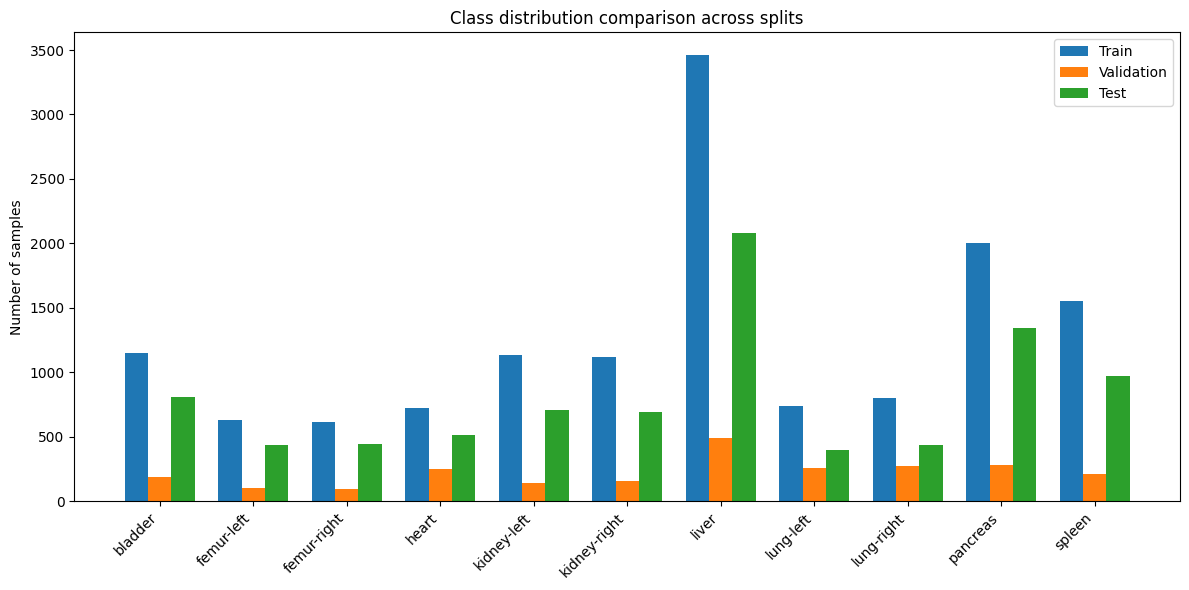

In [ ]:
x = np.arange(num_classes)
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, train_counts, width, label='Train')
plt.bar(x, val_counts, width, label='Validation')
plt.bar(x + width, test_counts, width, label='Test')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.title("Class distribution comparison across splits")
plt.ylabel("Number of samples")
plt.legend()
plt.tight_layout()
plt.show()

## Sample visualisation

### Setup

In [ ]:
def show_images(images, labels, title, class_names, n=None):
    if n is None:
        n = len(images)

    cols = 3
    rows = math.ceil(n / cols)

    plt.figure(figsize=(6, 2 * rows))

    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(class_names[int(labels[i])])
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_one_per_class(X, y, title):
    seen = {}
    images = []
    labels = []

    y = np.squeeze(y)

    for img, label in zip(X, y):
        label = int(label)

        if label not in seen:
            seen[label] = True
            images.append(img)
            labels.append(label)

        if len(seen) == len(class_names):
            break

    show_images(images, labels, title, class_names, n=len(class_names))

def show_samples_per_class(X, y, class_names, samples_per_class=5):
    y = np.squeeze(y)

    num_classes = len(class_names)

    for cls in range(num_classes):

        # get all images of this class
        idx = np.where(y == cls)[0]

        # handle edge case
        if len(idx) == 0:
            continue

        # randomly sample from this class
        chosen = np.random.choice(idx,
                                   size=min(samples_per_class, len(idx)),
                                   replace=False)

        images = X[chosen]
        labels = y[chosen]

        # plot grid
        cols = samples_per_class
        rows = 1

        plt.figure(figsize=(2 * cols, 2))

        for i in range(len(images)):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.title(class_names[int(labels[i])], fontsize=8)
            plt.axis('off')

        plt.suptitle(f"Class {cls}: {class_names[cls]}", fontsize=12)
        plt.tight_layout()
        plt.show()

### Random samples

/tmp/ipykernel_9642/2522428795.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(labels[i])])


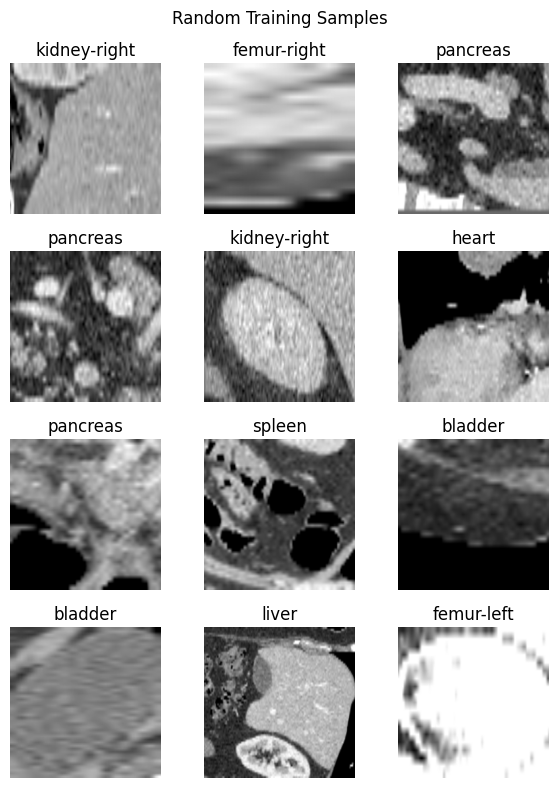

In [ ]:
idx = np.random.choice(len(X_train), 12, replace=False)

show_images(
    X_train[idx],
    y_train[idx],
    "Random Training Samples",
    class_names
)

### One per class

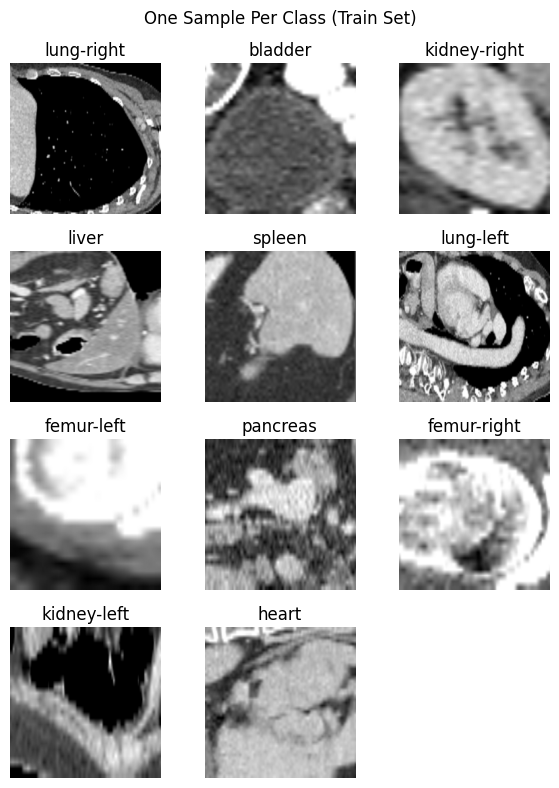

In [ ]:
show_one_per_class(X_train, y_train, "One Sample Per Class (Train Set)")

### Random per class

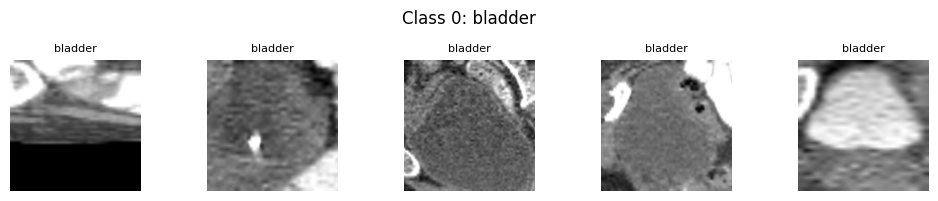

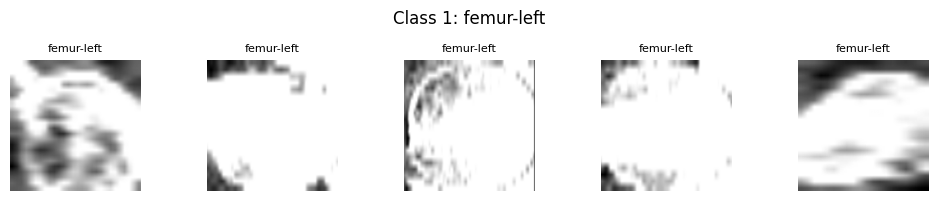

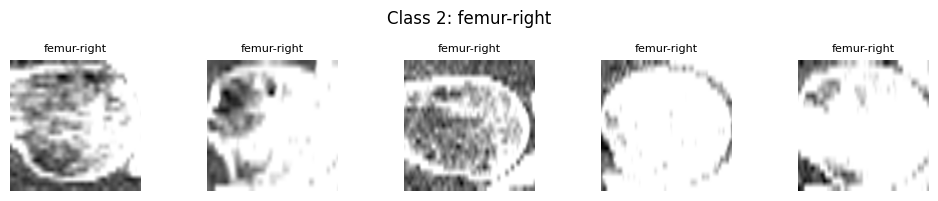

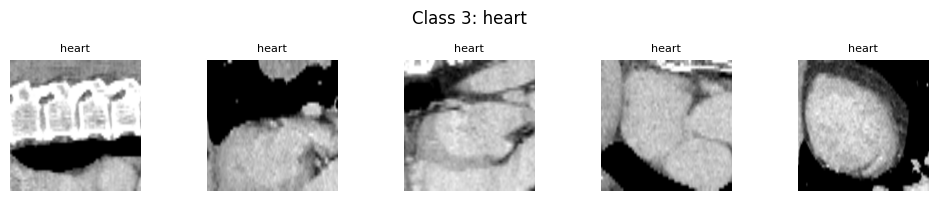

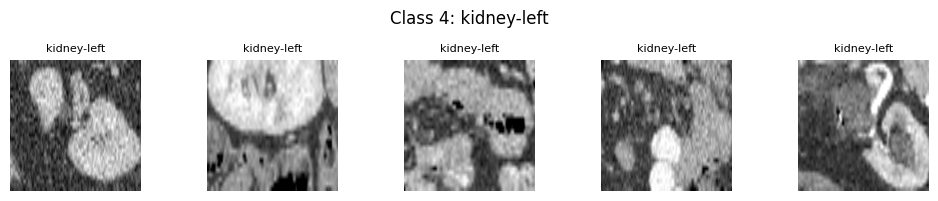

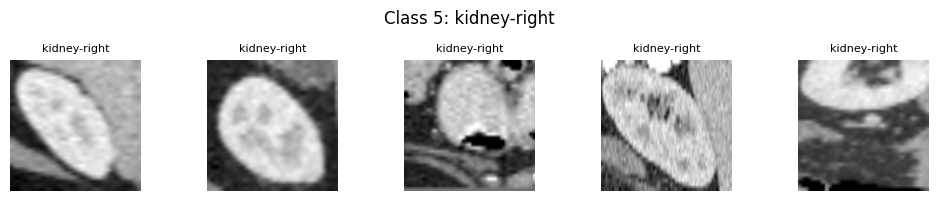

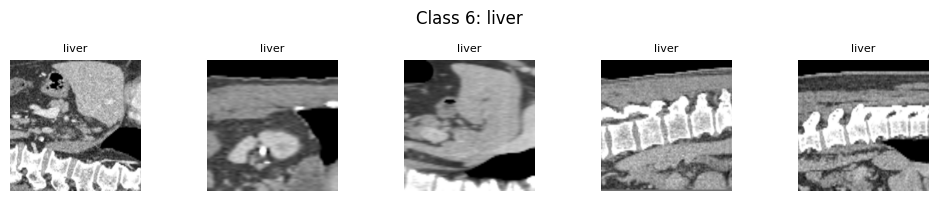

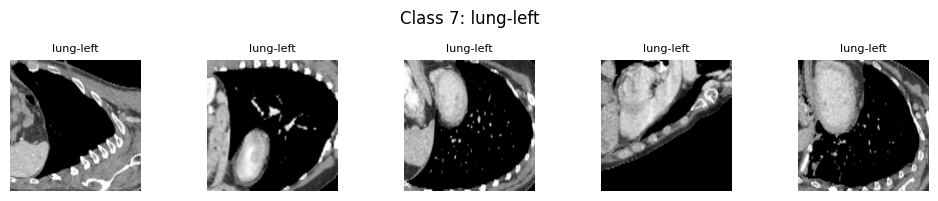

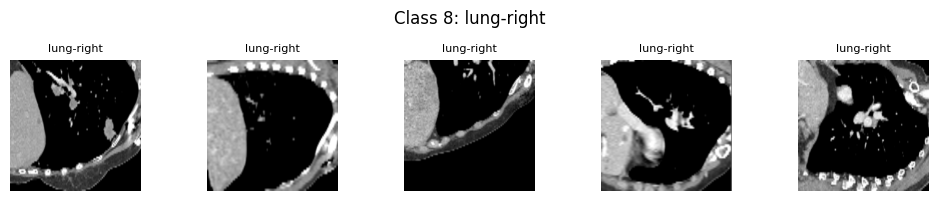

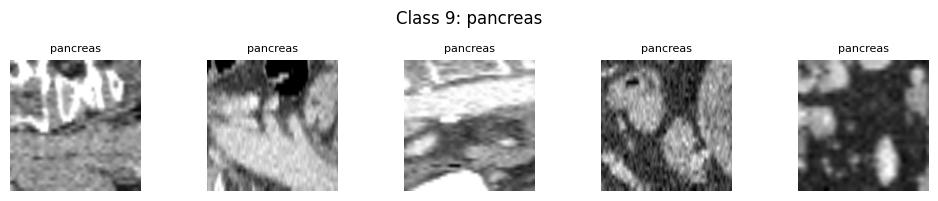

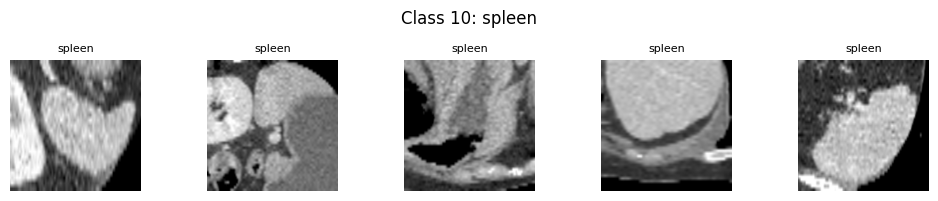

In [ ]:
show_samples_per_class(
    X_train,
    y_train,
    class_names,
    samples_per_class=5
)

# Q1

In [6]:
model = models.Sequential([
    layers.Input(shape=(X_train_flat.shape[1],)),
    layers.Dense(100, activation='relu'),   # hidden layer
    layers.Dense(len(set(y_train.flatten())), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=10,
    batch_size=32
)

test_loss, test_acc = model.evaluate(X_test_flat, y_test)
print("Test accuracy:", test_acc)

W0000 00:00:1775696777.377627   10919 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1775696777.383930   10919 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1775696777.600338   10919 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Epoch 1/10


I0000 00:00:1775696790.374827   11804 service.cc:153] XLA service 0x7e83fc030340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775696790.375258   11804 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775696790.452106   11804 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775696790.636597   11804 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775696790.670126   11804 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_962__.12
I0000 00:00:1775696792.009434   12015 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 24 bytes spill stores, 24 bytes spill loads



 37/436 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1488 - loss: 21.7269

I0000 00:00:1775696793.258608   11804 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

436/436 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2841 - loss: 6.5255

I0000 00:00:1775696798.145770   12388 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 24 bytes spill stores, 24 bytes spill loads



436/436 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3456 - loss: 3.1628 - val_accuracy: 0.4507 - val_loss: 1.6478
Epoch 2/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4318 - loss: 1.7876 - val_accuracy: 0.4617 - val_loss: 1.5599
Epoch 3/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4462 - loss: 1.6698 - val_accuracy: 0.5412 - val_loss: 1.2803
Epoch 4/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4821 - loss: 1.5136 - val_accuracy: 0.5400 - val_loss: 1.3478
Epoch 5/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4852 - loss: 1.4666 - val_accuracy: 0.4396 - val_loss: 1.6329
Epoch 6/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4946 - loss: 1.4161 - val_accuracy: 0.4637 - val_loss: 1.4557
Epoch 7/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5073 - loss: 1.3693 - val_accuracy: 0.5196 - val_loss: 1.3647
Epoch 8/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5149 - loss: 1.3387 - val_accuracy: 0.5285 - val

I0000 00:00:1775696816.365372   13608 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 16 bytes spill stores, 16 bytes spill loads



276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4226 - loss: 1.6776
Test accuracy: 0.42256712913513184


## Q2

In [ ]:
# add code for Q2

In [ ]:
# add discussion for Q2

# Q3

In [ ]:
# add code for Q3

## Q4

In [ ]:
# add code for Q4

In [ ]:
# add discussion for Q4

## Q5

In [ ]:
# add code for Q5

In [ ]:
# add discussion for Q5

## Q6

In [ ]:
# add code for Q6

In [ ]:
# add discussion for Q6

## Q7

In [ ]:
# add code for Q7

In [ ]:
# add discussion for Q7

# References (text)

List any references you may have used in your document before, using one of the established referencing system (e.g. IEEE, Harvard, etc).